# clean_swaps

In [ ]:
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
from util import pose_df_to_movement_ds, plot_speed, shade_mask_regions, clean_swaps_refactor
from aeon.dj_pipeline import fetch_stream, tracking, acquisition
from aeon.dj_pipeline.utils import tracking_utils
from matplotlib import pyplot as plt
from movement.kinematics import compute_speed, compute_pairwise_distances
from movement.transforms import scale

2025-06-23 14:12:46.323 | WARNING  | pkg_resources:<module>:98 - c:\Users\locha\Documents\Work\swc-aeon_analysis\.venv\Lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

[2025-06-23 14:12:56,619][INFO]: DataJoint 0.14.4 connected to chuan@localhost:3306


## Query centroid data from the database

### social0.2-aeon3

In [159]:
start_time = pd.Timestamp("2024-02-09 17:00:00")
end_time = start_time + pd.Timedelta(minutes=10)
key = {
    "experiment_name": "social0.2-aeon3",
    "chunk_start": start_time.floor("h"),
}

### social0.4-aeon4

In [14]:
start_time = pd.Timestamp("2024-08-28 21:10:00")
end_time = start_time + pd.Timedelta(hours=1)
key = {
    "experiment_name": "social0.4-aeon4",
    "chunk_start": start_time.floor("h"),
}

In [160]:
centroid_query = (
    tracking.SLEAPTracking.PoseIdentity.proj("identity_name", "identity_likelihood")
    * tracking.SLEAPTracking.AnchorPart
    & key
)
df = fetch_stream(centroid_query)[start_time:end_time]
df = df.sort_index()
ids = df["identity_name"].unique()
active_region_query = acquisition.EpochConfig.ActiveRegion & (acquisition.Chunk & key)
region_df = active_region_query.fetch(format="frame")

[2025-06-23 16:59:14,095][WARNING]: Reconnecting to MySQL server.


In [ ]:
df_fake = df[
    ~(
        (df.index >= start_time)
        & (df.index < start_time + pd.Timedelta(minutes=1))
        & (df["identity_name"] == "BAA-1104045")
    )
]
df_fake

,identity_name,identity_likelihood,x,y,likelihood
time,,,,,
2024-02-09 17:00:00.000,BAA-1104047,0.995592,235.557098,770.807373,1.002148
2024-02-09 17:00:00.020,BAA-1104047,0.995177,234.840759,765.615723,1.008761
2024-02-09 17:00:00.040,BAA-1104047,0.996676,232.434937,760.415771,1.028935
2024-02-09 17:00:00.060,BAA-1104047,0.997065,230.099091,755.233521,1.021770
2024-02-09 17:00:00.080,BAA-1104047,0.995043,229.482407,750.184326,1.019024
...,...,...,...,...,...
2024-02-09 17:09:59.960,BAA-1104045,0.806365,200.322510,565.655273,0.947517
2024-02-09 17:09:59.980,BAA-1104047,0.999927,616.181396,736.643738,0.949583
2024-02-09 17:09:59.980,BAA-1104045,0.829023,200.317612,565.655518,0.949583


In [ ]:
df_fake_clean = tracking_utils.clean_swaps(df_fake, region_df)

Cleaning frames:   0%|          | 0/27000 [00:00<?, ?it/s]

In [ ]:
df_raw = df.copy(deep=True)
df_clean = tracking_utils.clean_swaps(df_raw, region_df)
df_adjusted = clean_swaps_refactor(df_raw, region_df)
df_raw.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_raw["part"] = "centroid"
df_adjusted.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_adjusted["part"] = "centroid"
df_clean.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_clean["part"] = "centroid"
df_clean.equals(df_adjusted)

Cleaning frames:   0%|          | 0/30000 [00:00<?, ?it/s]

Cleaning frames:   0%|          | 0/30000 [00:00<?, ?it/s]

False

## Convert to movement dataset

In [205]:
ds_centroid = pose_df_to_movement_ds(df_raw)
ds_centroid_clean = pose_df_to_movement_ds(df_clean).reindex_like(ds_centroid)
ds_centroid_adjusted = pose_df_to_movement_ds(df_adjusted).reindex_like(ds_centroid)

## Plot position and inter-mouse distances

In [ ]:
(
    diff_mask.where(diff_mask, drop=True).time - ds_centroid.time.values[0]
).values / np.timedelta64(1, "s") * 50

array([ 7306., 10031., 10032., 10033., 10037., 11103., 11104., 14808.,
       14809., 17732., 17733., 17734., 17735., 22440., 26026.])

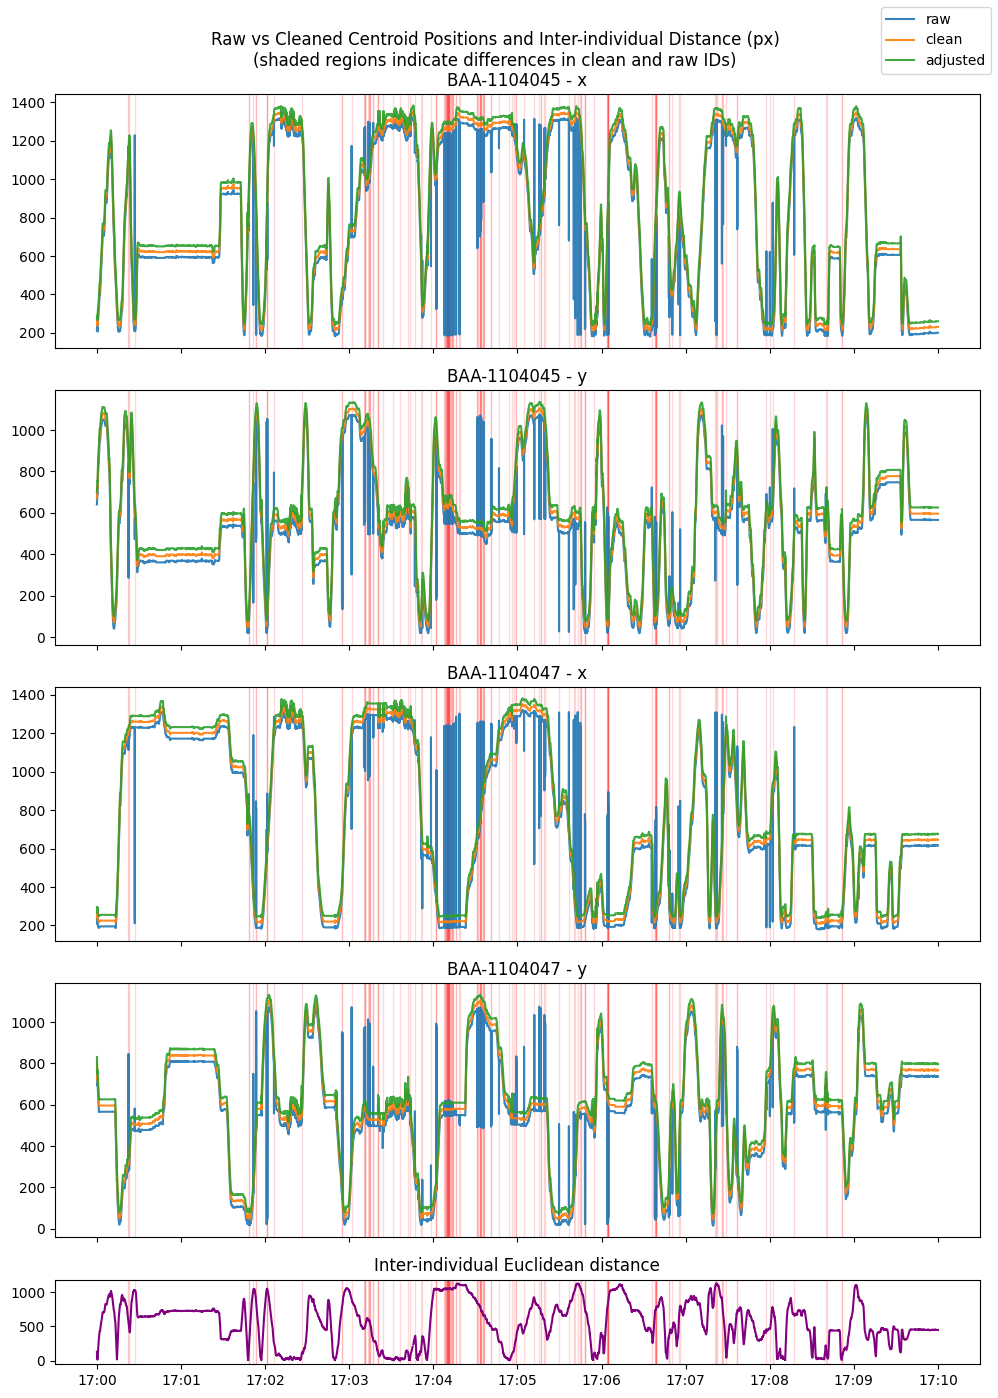

In [229]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = xr.DataArray(
    (
        ~np.isclose(
            ds_centroid_clean.position.squeeze(),
            ds_centroid.position.squeeze(),
            equal_nan=True,
        )
    )[:, 0, 0],
    dims=["time"],
    coords={"time": ds_centroid_clean.time},
)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and raw IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

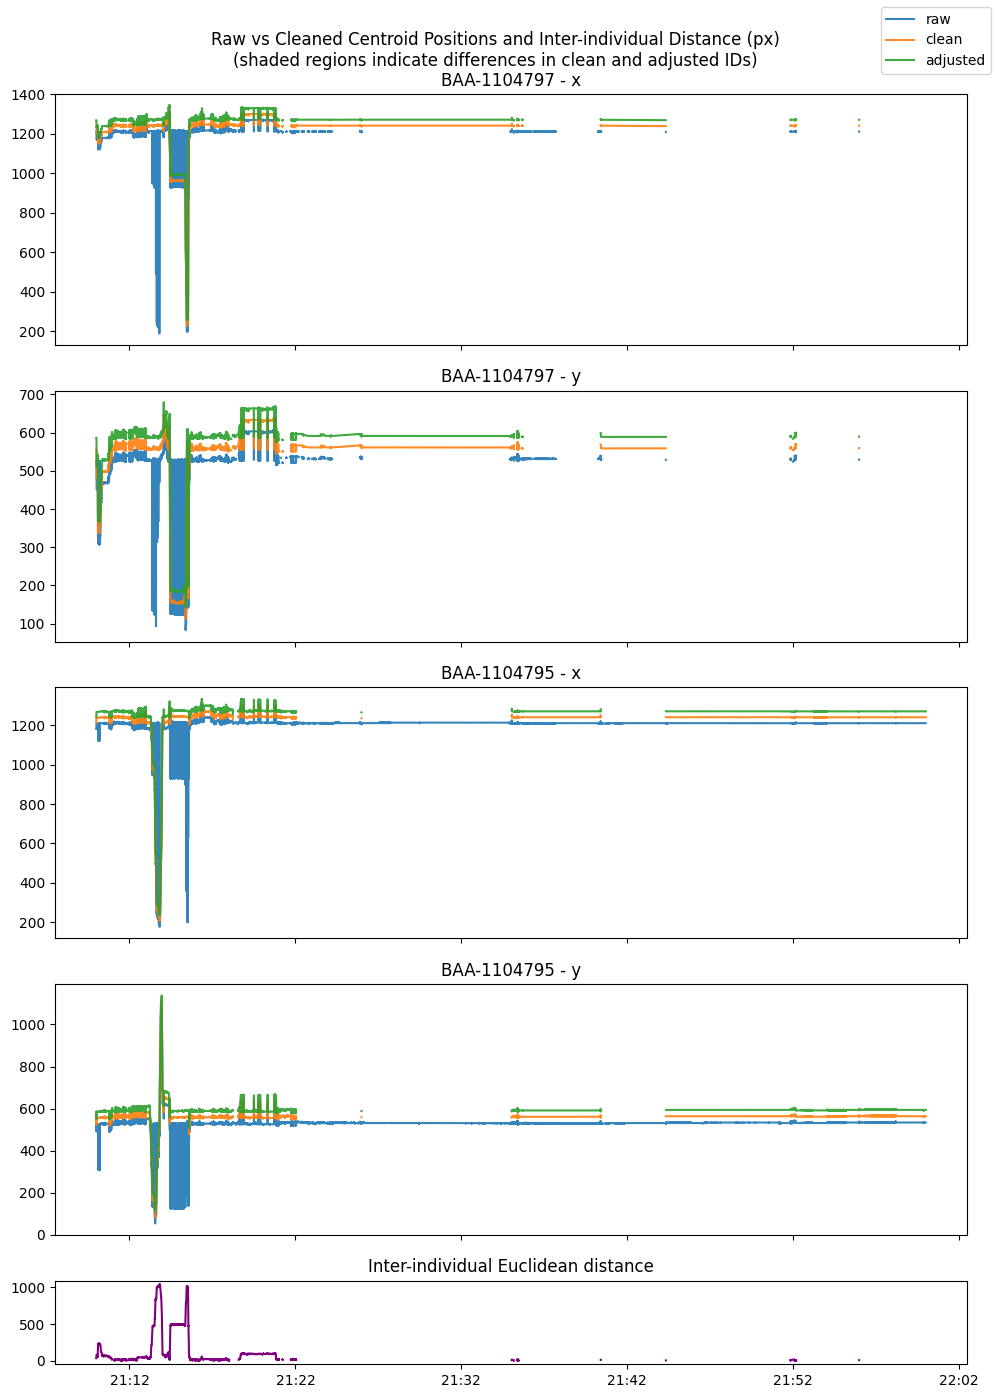

In [157]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = xr.DataArray(
    (
        ~np.isclose(
            ds_centroid_clean.position.squeeze(),
            ds_centroid_adjusted.position.squeeze(),
            equal_nan=True,
        )
    )[:, 0, 0],
    dims=["time"],
    coords={"time": ds_centroid_clean.time},
)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

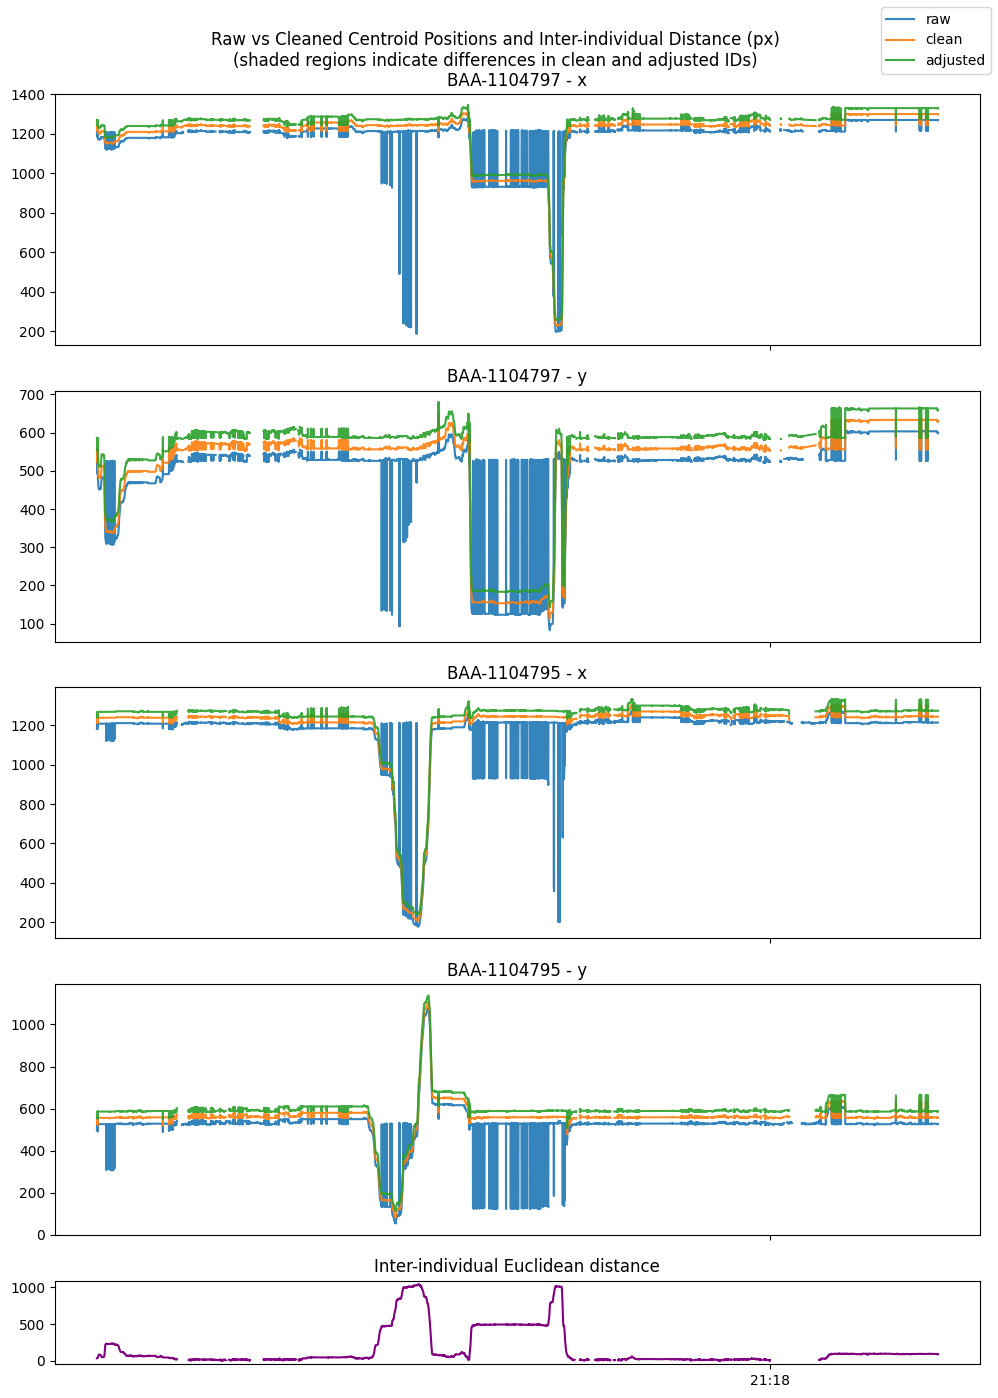

In [158]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = xr.DataArray(
    (
        ~np.isclose(
            ds_centroid_clean.position.squeeze(),
            ds_centroid_adjusted.position.squeeze(),
            equal_nan=True,
        )
    )[:, 0, 0],
    dims=["time"],
    coords={"time": ds_centroid_clean.time},
).sel(time=slice(start_time, start_time + pd.Timedelta(minutes=10)))
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
).sel(time=slice(start_time, start_time + pd.Timedelta(minutes=10)))
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(
                space=space,
                individuals=ind,
                time=slice(start_time, start_time + pd.Timedelta(minutes=10)),
            )
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## Compute and plot speed (cm/s)

In [212]:
PIXEL_SCALE = 0.192  # 1 px = 0.192 cm
# Compute speed in cm/s for both raw and cleaned centroid positions
ds_centroid["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid.time,
)
ds_centroid_clean["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_clean.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_clean.time,
)
ds_centroid_adjusted["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_adjusted.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_adjusted.time,
)

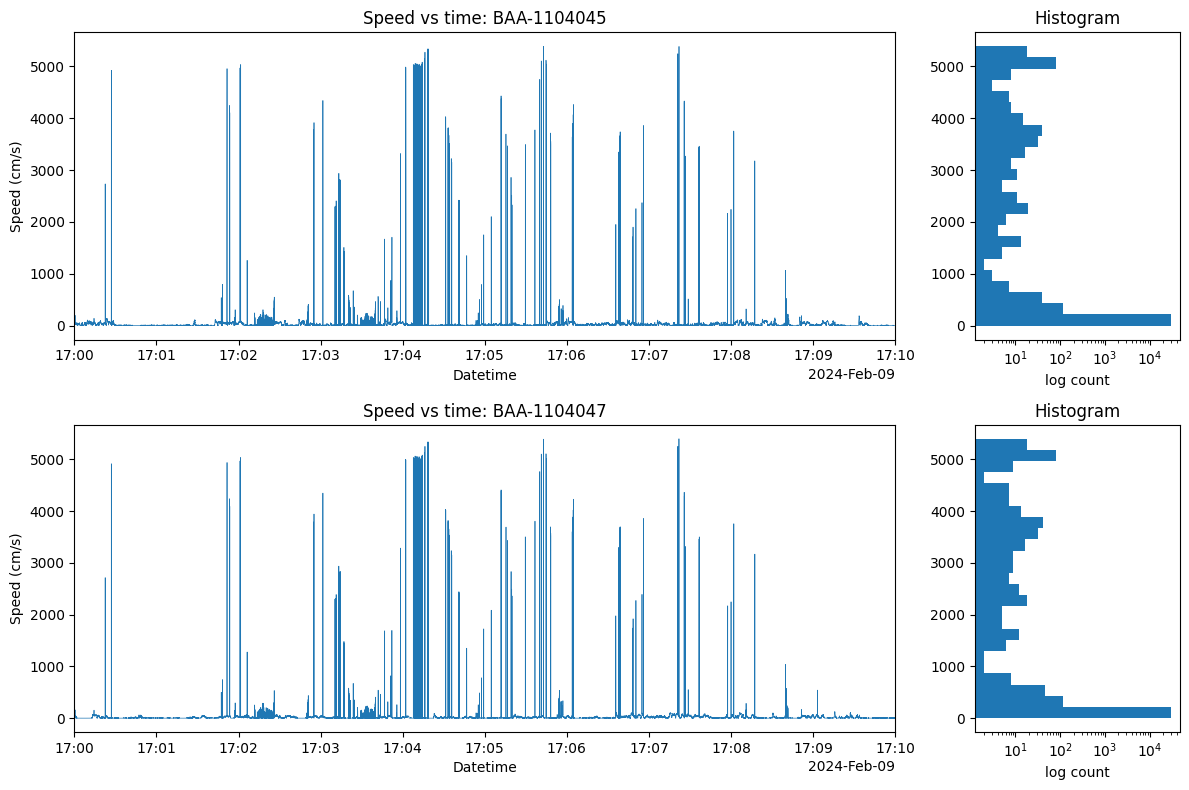

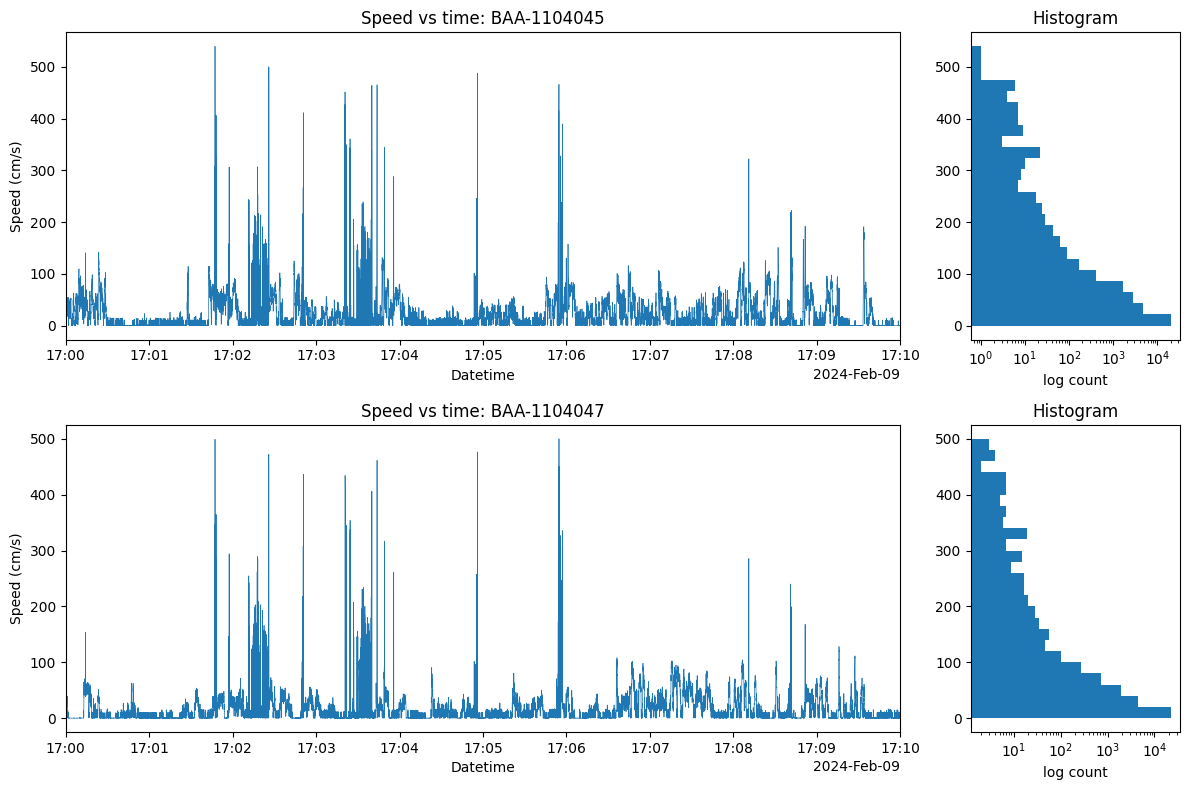

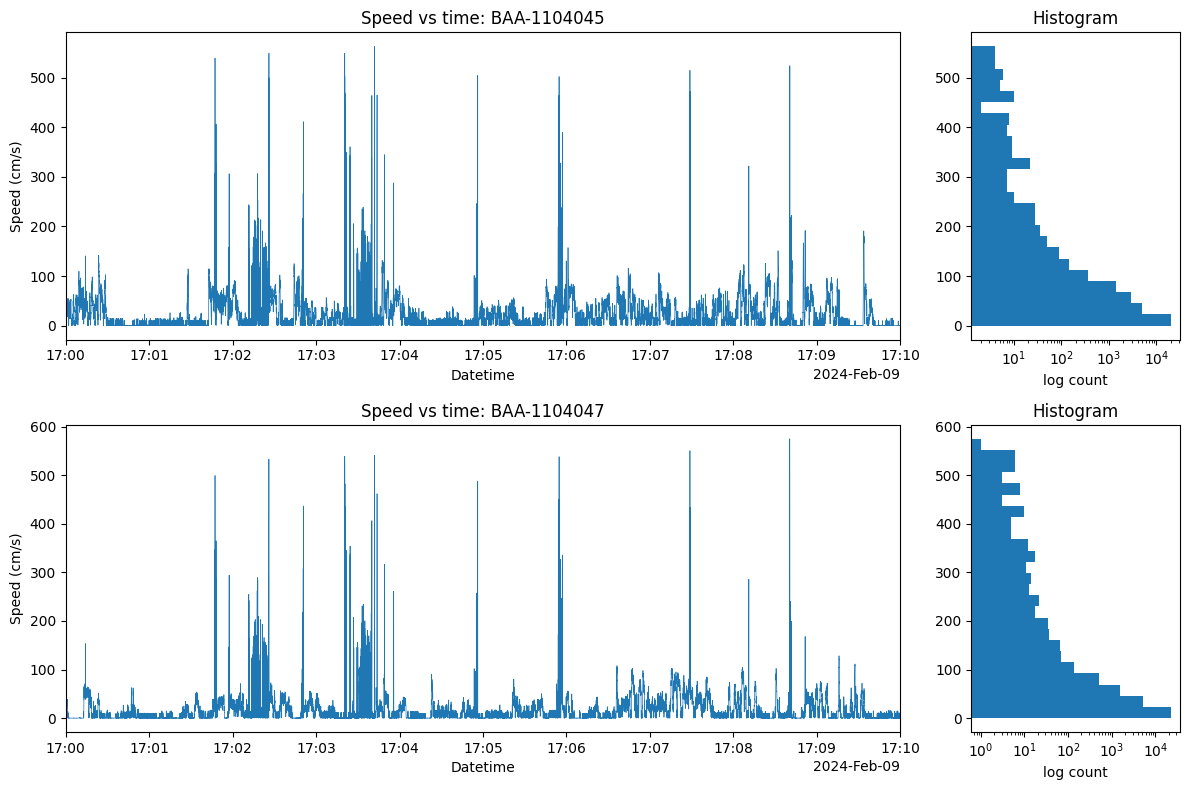

In [213]:
plot_speed(ds_centroid.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_clean.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_adjusted.speed_cm_per_sec.sel(keypoints="centroid"))

## Save to netCDF file for visualisation in movement GUI

In [208]:
ds_centroid.to_netcdf("raw-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_clean.to_netcdf("clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_adjusted.to_netcdf(
    "review-clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc"
)